In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00


In [3]:
from ultralytics import RTDETR

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/transformed_datasets/WilderPerson/gaussian_faceblur_dataset.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/gaussian_faceblur_dataset.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [5]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/gaussian_faceblur_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [6]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [7]:
import glob

ROOT = "/content/final-year-research/dataset"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 10098
valid images: 3284
valid labels: 3284


In [8]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB


In [9]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/dataset",
    "train": "/content/final-year-research/dataset/train/images",
    "val": "/content/final-year-research/dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

YAML fixed! Now defining 2 classes (0 and 1).


Image path: /content/final-year-research/dataset/valid/images/000098_jpg.rf.2dff2658ee31a0988b9f65683bdd69af.jpg


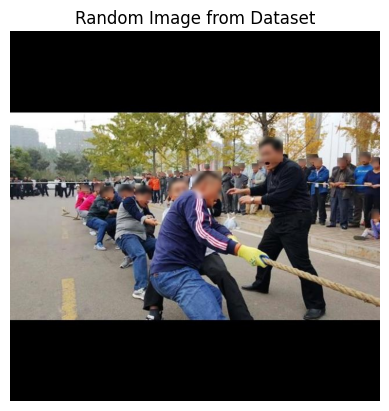

In [12]:
import os
import random
import matplotlib.pyplot as plt
import cv2

# Path to extracted dataset
dataset_path = f"{WORK_DIR}/dataset"

# Collect all image paths
image_extensions = ('.jpg', '.jpeg', '.png')
all_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, file))

# Pick a random image
random_image_path = random.choice(all_images)

# Read and display image
img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Random Image from Dataset")
plt.axis('off')

print("Image path:", random_image_path)

In [13]:
model = RTDETR("rtdetr-l.pt")

In [ ]:
model.train(
    data="/content/final-year-research/WilderPerson_colab.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/final-year-research/runs",
    name="rtdetr_wilderperson_blur_research_v1"
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_wilderperson_blur_research_v1, nbs=64, nms=False, opset=None,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      38.8G     0.8074     0.3656     0.1243          8       1280: 0% ──────────── 3/1263 1.3s/it 5.2s<26:16WARNING ⚠️ CUDA out of memory with batch=8. Reducing to batch=4 and retrying (2/3).
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1817.6±1183.7 MB/s, size: 79.7 KB)
train: Scanning /content/final-year-research/dataset/train/labels.cache... 10098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10098/10098 3.9Git/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1143.0±881.1 MB/s, size: 105.6 KB)
val: Scanning /content/final-year-research/dataset/valid/labels.cache... 3284 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3284/3284 211.9Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining bes

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      31.2G     0.8387     0.3499     0.1529          4       1280: 3% ──────────── 70/2525 2.4it/s 36.1s<17:18


KeyboardInterrupt: 